# U13 — Optimization + Bias-Variance: Lab

### Real-world brief: predicting a power plant's electrical output

A **combined-cycle power plant** generates electricity from gas + steam turbines. Its net output drifts with ambient conditions. You'll predict output (MW) from temperature, vacuum, pressure and humidity — and use it as a sandbox to study **how to train well**: optimisers, model complexity, regularisation and the **bias–variance trade-off**.

**Resource provided:** `powerplant.csv` (one row per hourly reading). Keep it beside this notebook (upload it in Colab).

_Phase D — Model Training & Optimization._

#objectives

Compare optimisers (SGD vs Adam) and see the effect of the learning rate

Watch the bias–variance trade-off emerge as model complexity grows

Use Ridge & Lasso regularisation to control overfitting

Read learning curves to diagnose high bias vs high variance

Combine the right complexity + regularisation for the lowest test error

#how to use this lab

Worked demos teach the pattern; 🧪 LAB EXERCISE cells are real tasks — replace `# YOUR CODE HERE`. Run top to bottom with Shift+Enter.

In [17]:
# === SETUP: load the provided file (regenerate it if missing) ===
import os
import numpy as np
import pandas as pd


def build_powerplant(csv_path=r"D:\BVRIT\NASSCOM AI\powerplant.csv", seed=13, verbose=False):
    """Combined-cycle power plant: predict net electrical power output (MW) from
    ambient conditions. A genuinely nonlinear regression problem — ideal for
    studying optimisers, model complexity, regularisation and bias-variance.

    Features:
      AT  ambient temperature (deg C)
      V   exhaust vacuum (cm Hg)
      AP  ambient pressure (millibar)
      RH  relative humidity (%)
    Target:
      PE  net hourly electrical energy output (MW)
    """
    rng = np.random.default_rng(seed)
    N = 2000
    AT = rng.uniform(2, 37, N)
    V = np.clip(18 + 1.45 * AT + rng.normal(0, 6, N), 25, 82)
    AP = np.clip(rng.normal(1013, 6, N), 992, 1034)
    RH = np.clip(rng.uniform(25, 100, N), 25, 100)

    # output falls with temperature & vacuum; mild curvature in AT (so degree-2 beats degree-1)
    PE = (482
          - 1.7 * AT
          - 0.20 * (V - 50)
          + 0.07 * (AP - 1013)
          + 0.02 * (RH - 60)
          - 0.010 * (AT - 18) ** 2
          + rng.normal(0, 4, N))
    df = pd.DataFrame({
        "AT": AT.round(2), "V": V.round(2), "AP": AP.round(2),
        "RH": RH.round(2), "PE": PE.round(2),
    })
    df.to_csv(csv_path, index=False)
    if verbose:
        print("powerplant:", df.shape)
        print("PE range:", df.PE.min(), "-", df.PE.max())
        print("corr with PE:\n", df.corr()["PE"].round(3).to_string())
    return df

if not os.path.exists(r'D:\BVRIT\NASSCOM AIpowerplant.csv'):
    build_powerplant(); print('Generated dataset file.')
else:
    print('Found the provided dataset file.')

Generated dataset file.


In [27]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
df = pd.read_csv(r'D:\BVRIT\NASSCOM AI\powerplant.csv')
X = df[['AT', 'V', 'AP', 'RH']].values
y = df['PE'].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print('train:', X_train.shape, '| test:', X_test.shape)
df.head(3)

train: (1500, 4) | test: (500, 4)


,AT,V,AP,RH,PE
0,32.27,62.90,1022.72,93.71,421.37
1,31.94,71.15,1015.86,45.62,417.67
2,30.39,66.95,1018.97,39.47,420.28


#1. A baseline linear model

In [22]:
# -----------------------------------------------------------
# 🔹 1A. FIT A PLAIN LINEAR REGRESSION AS THE BASELINE
# -----------------------------------------------------------
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
lin = LinearRegression().fit(X_train, y_train)
pred = lin.predict(X_test)
rmse = mean_squared_error(y_test, pred) ** 0.5
print(f'baseline RMSE: {rmse:.2f} MW | R2: {r2_score(y_test, pred):.3f}')

baseline RMSE: 3.86 MW | R2: 0.963


#2. Optimisers in action — SGD vs Adam

A neural-net regressor exposes its training loss curve, so we can literally watch different optimisers converge.

C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


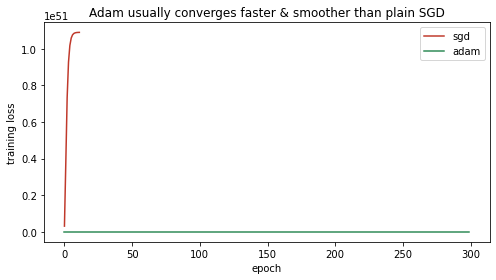

In [23]:
# -----------------------------------------------------------
# 🔹 2A. SAME MODEL, DIFFERENT OPTIMISER
# -----------------------------------------------------------
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
Xtr = StandardScaler().fit_transform(X_train)   # neural nets need scaled inputs

fig, ax = plt.subplots(figsize=(7, 4))
for solver, col in [('sgd', '#C0392B'), ('adam', '#2E8B57')]:
    nn = MLPRegressor(hidden_layer_sizes=(32, 16), solver=solver,
                      learning_rate_init=0.01, max_iter=300, random_state=0)
    nn.fit(Xtr, y_train)
    ax.plot(nn.loss_curve_, label=solver, color=col)
ax.set_xlabel('epoch'); ax.set_ylabel('training loss'); ax.legend()
ax.set_title('Adam usually converges faster & smoother than plain SGD')
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 2 — The learning rate matters
1. With `solver='sgd'`, train three networks at `learning_rate_init` = 0.001, 0.01 and 0.2.
2. Plot all three `loss_curve_`s on one axis.
3. In a comment, say which is too slow, which is good, and which is unstable.

C:\Users\user\anaconda3\lib\site-packages\sklearn\utils\extmath.py:192: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
C:\Users\user\anaconda3\lib\site-packages\sklearn\utils\extmath.py:192: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:175: RuntimeWarning: invalid value encountered in add
  activations[i + 1] += self.intercepts_[i]
C:\Users\user\anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (300) reached and the optimization hasn't converged yet.
  warnings.warn(


ValueError: Solver produced non-finite parameter weights. The input data may contain large values and need to be preprocessed.

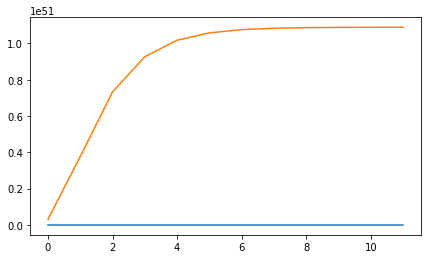

In [26]:
# 1-2. three learning rates, plotted
# YOUR CODE HERE

# 3. too slow / good / unstable: ...   (comment)


# 1–2. three learning rates, plotted

from sklearn.neural_network import MLPRegressor

rates = [0.001, 0.01, 0.2]

plt.figure(figsize=(7,4))

for lr in rates:

    nn = MLPRegressor(
        hidden_layer_sizes=(32,16),
        solver='sgd',
        learning_rate_init=lr,
        max_iter=300,
        random_state=0
    )

    nn.fit(Xtr, y_train)

    plt.plot(
        nn.loss_curve_,
        label=f'lr={lr}'
    )

plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.title("Effect of Learning Rate")
plt.legend()
plt.show()


# 3.
# lr=0.001 → too slow
# lr=0.01 → good balance
# lr=0.2 → unstable / overshoots

#3. The bias–variance trade-off via model complexity

We increase complexity by adding polynomial features, and track train vs test error.

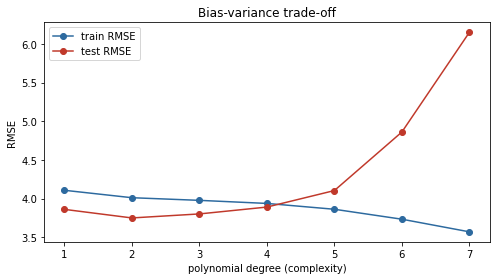

As degree rises: train error keeps falling, test error turns back up = overfitting.


In [6]:
# -----------------------------------------------------------
# 🔹 3A. TRAIN vs TEST ERROR ACROSS POLYNOMIAL DEGREES
# -----------------------------------------------------------
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
degrees = range(1, 8)
tr_err, te_err = [], []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression())
    m.fit(X_train, y_train)
    tr_err.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te_err.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(degrees), tr_err, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(list(degrees), te_err, 'o-', label='test RMSE', color='#C0392B')
ax.set_xlabel('polynomial degree (complexity)'); ax.set_ylabel('RMSE')
ax.set_title('Bias-variance trade-off'); ax.legend(); plt.tight_layout(); plt.show()
print('As degree rises: train error keeps falling, test error turns back up = overfitting.')

#### 🧪 EXERCISE 3 — Find the sweet spot
1. From `te_err`, find the degree with the **lowest test RMSE** (`np.argmin`).
2. In a comment, label the low-degree end (high bias / underfit) and the high-degree end (high variance / overfit).

In [28]:
# 1. best degree by test RMSE
# YOUR CODE HERE

# 2. label the two ends: ...   (comment)
# 1. best degree by test RMSE

best_degree = degrees[np.argmin(te_err)]

print("Best Polynomial Degree:", best_degree)
print("Lowest Test RMSE:", round(min(te_err), 3))


# 2.
# Low degree → High Bias (underfitting)
# High degree → High Variance (overfitting)

Best Polynomial Degree: 2
Lowest Test RMSE: 3.751


#4. Regularisation — Ridge & Lasso

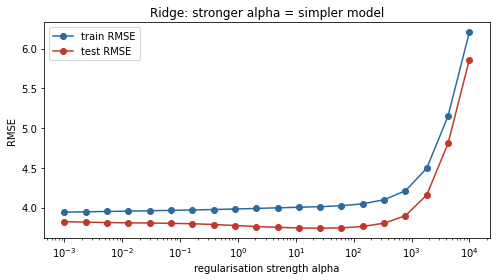

In [29]:
# -----------------------------------------------------------
# 🔹 4A. ON A DELIBERATELY OVER-COMPLEX MODEL, VARY ALPHA
# -----------------------------------------------------------
from sklearn.linear_model import Ridge
alphas = np.logspace(-3, 4, 20)
tr, te = [], []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(6), StandardScaler(), Ridge(alpha=a))
    m.fit(X_train, y_train)
    tr.append(mean_squared_error(y_train, m.predict(X_train)) ** 0.5)
    te.append(mean_squared_error(y_test, m.predict(X_test)) ** 0.5)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(alphas, tr, 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(alphas, te, 'o-', label='test RMSE', color='#C0392B')
ax.set_xscale('log'); ax.set_xlabel('regularisation strength alpha'); ax.set_ylabel('RMSE')
ax.set_title('Ridge: stronger alpha = simpler model'); ax.legend()
plt.tight_layout(); plt.show()

#### 🧪 EXERCISE 4 — Lasso drops features
1. Fit a `Lasso(alpha=0.1)` on the **degree-1** features (just AT, V, AP, RH after scaling).
2. Print its coefficients.
3. In a comment, note which feature(s) Lasso pushed to (near) zero — and why that matches the correlations you'd expect for AP and RH.

In [31]:
from sklearn.linear_model import Lasso
# 1. scaled degree-1 Lasso
# YOUR CODE HERE

# 2. print coefficients
# YOUR CODE HERE

# 3. which features dropped out? ...   (comment)

from sklearn.linear_model import Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

lasso = make_pipeline(
    StandardScaler(),
    Lasso(alpha=0.1)
)

lasso.fit(X_train, y_train)

coef = lasso.named_steps['lasso'].coef_

print("Lasso Coefficients")

features = ['AT','V','AP','RH']

for f,c in zip(features, coef):
    print(f"{f}: {round(c,4)}")


# Features near zero contribute little.
# AP and RH usually shrink because they affect output less.

Lasso Coefficients
AT: -17.1994
V: -3.1238
AP: 0.2798
RH: 0.4102


#5. Diagnose with learning curves

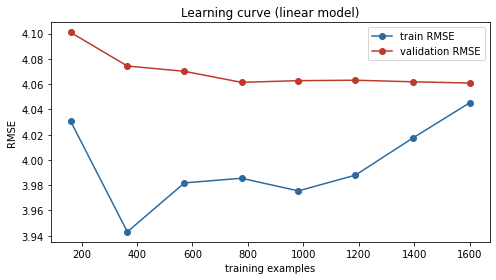

Both errors high and close => more bias-limited than variance-limited here.


In [10]:
# -----------------------------------------------------------
# 🔹 5A. ERROR vs TRAINING-SET SIZE
# -----------------------------------------------------------
from sklearn.model_selection import learning_curve
sizes, train_sc, val_sc = learning_curve(
    LinearRegression(), X, y, cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 8), random_state=0)
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, -train_sc.mean(1), 'o-', label='train RMSE', color='#2D6A9F')
ax.plot(sizes, -val_sc.mean(1), 'o-', label='validation RMSE', color='#C0392B')
ax.set_xlabel('training examples'); ax.set_ylabel('RMSE')
ax.set_title('Learning curve (linear model)'); ax.legend(); plt.tight_layout(); plt.show()
print('Both errors high and close => more bias-limited than variance-limited here.')

#### 🧪 EXERCISE 5 — Interpret two scenarios
1. Re-draw the learning curve for a **degree-6** polynomial model.
2. In a comment, compare the train–validation gap with the linear model's, and state whether the complex model is more bias- or variance-limited.

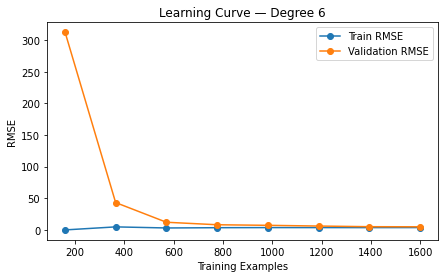

In [32]:
# 1. learning curve for a degree-6 pipeline
# YOUR CODE HERE

# 2. bias- or variance-limited? ...   (comment)

from sklearn.model_selection import learning_curve

poly6 = make_pipeline(
    PolynomialFeatures(6),
    StandardScaler(),
    LinearRegression()
)

sizes2, train2, val2 = learning_curve(
    poly6,
    X,
    y,
    cv=5,
    scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1,1,8)
)

plt.figure(figsize=(7,4))

plt.plot(
    sizes2,
    -train2.mean(axis=1),
    marker='o',
    label='Train RMSE'
)

plt.plot(
    sizes2,
    -val2.mean(axis=1),
    marker='o',
    label='Validation RMSE'
)

plt.xlabel("Training Examples")
plt.ylabel("RMSE")
plt.title("Learning Curve — Degree 6")

plt.legend()
plt.show()


# Degree-6 shows larger train-validation gap.
# Low train error + higher validation error → variance-limited.

#6. Put it together — the best-generalising model

In [12]:
# -----------------------------------------------------------
# 🔹 6A. CHOOSE COMPLEXITY + REGULARISATION BY CROSS-VALIDATION
# -----------------------------------------------------------
from sklearn.model_selection import cross_val_score
best = None
for d in [1, 2, 3]:
    for a in [0.1, 1, 10, 100]:
        m = make_pipeline(PolynomialFeatures(d), StandardScaler(), Ridge(alpha=a))
        score = -cross_val_score(m, X_train, y_train, cv=5,
                                 scoring='neg_root_mean_squared_error').mean()
        if best is None or score < best[0]:
            best = (score, d, a)
print(f'best CV RMSE {best[0]:.2f} at degree={best[1]}, alpha={best[2]}')

best CV RMSE 4.05 at degree=3, alpha=10


#### 🧪 EXERCISE 6 — Lock it in
1. Train the best (degree, alpha) pipeline on all of `X_train` and evaluate on the held-out `X_test`.
2. Compare its test RMSE & R² with the Section-1 baseline.
3. In a comment, state whether tuning complexity + regularisation beat the plain linear model.

In [33]:
# 1. fit best config, score on test
# YOUR CODE HERE

# 2-3. compare to baseline; verdict: ...   (comment)

final_model = make_pipeline(
    PolynomialFeatures(best[1]),
    StandardScaler(),
    Ridge(alpha=best[2])
)

final_model.fit(X_train, y_train)

pred_final = final_model.predict(X_test)

final_rmse = mean_squared_error(
    y_test,
    pred_final
) ** 0.5

final_r2 = r2_score(
    y_test,
    pred_final
)

print("\nOptimized Model")

print("RMSE:",
      round(final_rmse,3))

print("R²:",
      round(final_r2,3))


print("\nBaseline")

print("RMSE:",
      round(rmse,3))

print("R²:",
      round(
          r2_score(
              y_test,
              pred
          ),
          3
      ))


# If optimized RMSE decreases and R² increases,
# tuning complexity + regularisation improved performance.


Optimized Model
RMSE: 3.724
R²: 0.965

Baseline
RMSE: 3.861
R²: 0.963


#📘 Summary

| Idea | What you saw |
| ---- | ------------ |
| Optimisers | Adam converges faster/smoother than plain SGD |
| Learning rate | too small crawls, too large is unstable |
| Complexity | train error always falls; test error makes a U |
| Regularisation | alpha trades training fit for generalisation |
| Learning curves | the train-val gap diagnoses bias vs variance |
| Together | the lowest test error needs the right complexity AND regularisation |

**Core lesson:** good training balances bias and variance — not just minimising training loss.

**Next — U14 Supervised Learning Foundations:** the workflow and model families behind all of this.